<a href="https://colab.research.google.com/github/Milioes/INST414-Module1_Milioes/blob/main/INST414_Medium_Post.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INST 414: Module 1

Montgomery County Crime Network Analysis

Data: Montgomery County Open Data – Crime

Date: September 22, 2026

Agency: Montgomery County Police Department (MCPD)

Emilio Sanchez San Martin

In [34]:
# First, will import libraries
import networkx as nx

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
data = pd.read_csv('/content/Crime_20260922.csv')
data_mcpd = data[data['Agency'] == 'MCPD']

In [20]:
data_mcpd["Agency"].value_counts()

,count
Agency,
MCPD,1617


In [21]:
data_mcpd.head()

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,Start_Date_Time,End_Date_Time,NIBRS Code,Victims,Crime Name1,Crime Name2,...,PRA,Address Number,Street Prefix,Street Name,Street Suffix,Street Type,Latitude,Longitude,Police District Number,Location
0,201591675,2303,260041495,NaN,09/21/2026 10:13:00 PM,NaN,23C,1,Crime Against Property,Shoplifting,...,146,12000.0,NaN,CHERRY HILL,NaN,RD,39.05259,-76.9531,3D,"(39.0526, -76.9531)"
1,201591656,9108,260041476,NaN,09/21/2026 07:51:00 PM,NaN,90Z,1,Crime Against Society,All Other Offenses,...,329,NaN,NaN,SHOREFIELD,NaN,RD,39.05304,-77.0477,4D,"(39.053, -77.0477)"
2,201591676,1399,260041487,09/21/2026 07:27:56 PM,09/21/2026 07:27:00 PM,NaN,13B,1,Crime Against Person,Simple Assault,...,524,4400.0,NaN,RANDOLPH,NaN,RD,39.05539,-77.0836,4D,"(39.0554, -77.0836)"
3,201591653,9101,260041484,09/21/2026 06:49:51 PM,09/21/2026 06:49:00 PM,NaN,90Z,1,Crime Against Society,All Other Offenses,...,767,8400.0,NaN,TOWNE CREST,NaN,CT,39.14584,-77.1727,6D,"(39.1458, -77.1727)"
4,201591657,9021,260041478,09/21/2026 06:28:40 PM,09/21/2026 06:28:00 PM,09/21/2026 06:28:00 PM,90I,2,Crime Against Not a Crime,Runaway,...,721,15000.0,NaN,BROSCHART,NaN,RD,39.10179,-77.2003,6D,"(39.1018, -77.2003)"


We are working with 1617 rows focused on only the MCPD Agency data! MCPD is one consistent agency, so it's better to collect data from this agency alone. My stakeholder will be Montgomery County Police / crime analysts. From looking at the other agencies in the source, theres GDP, RCPD, TTPD, that are different departments of their own with their own practices on reporting. Better to use MCPD agency data.

Will Check for NA's and more important info!

In [22]:
data_mcpd[["City", "Crime Name2", "Agency"]].isna().sum()

,0
City,0
Crime Name2,0
Agency,0


In [23]:
data_mcpd["Crime Name2"].value_counts()

,count
Crime Name2,
All Other Offenses,514
Simple Assault,178
Shoplifting,133
Destruction/Damage/Vandalism of Property,83
Theft From Motor Vehicle,75
Motor Vehicle Theft,73
All other Larceny,63
Theft of Motor Vehicle Parts or Accessories,58
Drug/Narcotic Violations,52


In [24]:
data_mcpd["City"].value_counts()

,count
City,
SILVER SPRING,653
GERMANTOWN,205
ROCKVILLE,162
GAITHERSBURG,138
BETHESDA,137
POTOMAC,48
MONTGOMERY VILLAGE,47
CHEVY CHASE,45
DERWOOD,35


Oh man! We see that the 'All Other Offenses' has the MOST highest count, I would like to continue finding what offenses these are viewing the Crime Name 3 column. Let's check!

In [25]:
data_mcpd[data_mcpd["Crime Name2"] == "All Other Offenses"]["Crime Name3"].value_counts()

,count
Crime Name3,
POLICE INFORMATION,155
MENTAL ILLNESS - EMERGENCY PETITION,94
LOST PROPERTY,51
SUDDEN DEATH,47
MISSING PERSON,34
RECOVERED PROPERTY - MONT CO.,24
OBSTRUCT GOVT - VIOLATION OF A COURT ORDER,16
FUGITIVE FROM JUSTICE (OUT OF STATE),14
MENTAL ILLNESS,12


Ahh, we actually see that these type of 'crimes' are not actual BIG crimes, which is why they are labeled as 'All Other Offenses'. I am more focused on the categories that actually represent a meaningful crime type. I am going to exclude these records as I am more focused on bigger crimes in the area.

In [26]:
data_network = data_mcpd[
    data_mcpd["Crime Name2"].str.strip() != "All Other Offenses"
]

In [27]:
data_network["Crime Name2"].value_counts().head()

,count
Crime Name2,
Simple Assault,178
Shoplifting,133
Destruction/Damage/Vandalism of Property,83
Theft From Motor Vehicle,75
Motor Vehicle Theft,73


In [30]:
edges = (
    data_network
    .groupby(["City", "Crime Name2"])
    .size()
    .reset_index(name="Weight")
)

top_10_edges = edges.sort_values("Weight", ascending=False).head(10)
print(top_10_edges)

              City                                  Crime Name2  Weight
212  SILVER SPRING                               Simple Assault      68
211  SILVER SPRING                                  Shoplifting      67
193  SILVER SPRING     Destruction/Damage/Vandalism of Property      41
119     GERMANTOWN                               Simple Assault      36
206  SILVER SPRING                          Motor Vehicle Theft      31
213  SILVER SPRING                     Theft From Motor Vehicle      27
118     GERMANTOWN                                  Shoplifting      27
215  SILVER SPRING  Theft of Motor Vehicle Parts or Accessories      27
197  SILVER SPRING                     Drug/Narcotic Violations      25
180      ROCKVILLE                               Simple Assault      21


In [33]:
print("Communities", edges["City"].nunique())
print("Crime Categories", edges["Crime Name2"].nunique())
print("Connections:", len(edges))

Communities 25
Crime Categories 35
Connections: 224


Now that we see our results, anad we have our edges, we can work in the stage to make our NetworkX Graph and calculate what makes the community more important based on the nodes and edges we see!

In [48]:
g = nx.Graph()
print(g)

Graph with 0 nodes and 0 edges


Adding **Nodes!** We will do Two different types, Commmunity and Crime.

In [53]:
for city in edges["City"].unique():
  g.add_node(city, node_type = "Community")

In [54]:
for crime in edges["Crime Name2"].unique():
  g.add_node(crime, node_type = "Crime")

In [55]:
print(g)

Graph with 60 nodes and 0 edges


Adding **Edges!** We will now connect the community to crime categories and vise verse, storing the number of incidents as the edges weight.

In [56]:
for x, row in edges.iterrows():
  city = row["City"]
  crime = row["Crime Name2"]
  weight = row["Weight"]

  g.add_edge(city, crime, weight=weight)

In [59]:
print(g)

Graph with 60 nodes and 224 edges


Time to find the most important nodes. There are many methods to look for centralities of nodes and looking for an important one. For my project, I want to try to connect it with finding communities with highest crime or where a crime take place more than others. We will start with degree centrality.

In [62]:

degree_centrality = nx.degree_centrality(g)
print(degree_centrality)

{'ASHTON': 0.03389830508474576, 'BETHESDA': 0.3050847457627119, 'BOYDS': 0.05084745762711865, 'BROOKEVILLE': 0.03389830508474576, 'BURTONSVILLE': 0.1694915254237288, 'CHEVY CHASE': 0.2711864406779661, 'CLARKSBURG': 0.0847457627118644, 'DAMASCUS': 0.13559322033898305, 'DERWOOD': 0.2033898305084746, 'DICKERSON': 0.01694915254237288, 'GAITHERSBURG': 0.4406779661016949, 'GERMANTOWN': 0.3559322033898305, 'HIGHLAND': 0.01694915254237288, 'KENSINGTON': 0.13559322033898305, 'MONTGOMERY VILLAGE': 0.22033898305084745, 'MT AIRY': 0.01694915254237288, 'OLNEY': 0.13559322033898305, 'POOLESVILLE': 0.03389830508474576, 'POTOMAC': 0.1694915254237288, 'ROCKVILLE': 0.3220338983050847, 'SANDY SPRING': 0.01694915254237288, 'SILVER SPRING': 0.5254237288135594, 'SPENCERVILLE': 0.01694915254237288, 'TAKOMA PARK': 0.05084745762711865, 'WASHINGTON GROVE': 0.03389830508474576, 'Destruction/Damage/Vandalism of Property': 0.23728813559322035, 'Simple Assault': 0.2711864406779661, 'All other Larceny': 0.2203389830

To identify the important communities involved with certain crime categories, we will need to filter our results. I don't want to just see the most important node for a crime category, but I want to see which city/community has the biggest impact.

In [67]:
# Just for community
community_centrality = {
    node: score
    for node, score in degree_centrality.items()
    if g.nodes[node]["node_type"] == "Community"
}
print(community_centrality)

{'ASHTON': 0.03389830508474576, 'BETHESDA': 0.3050847457627119, 'BOYDS': 0.05084745762711865, 'BROOKEVILLE': 0.03389830508474576, 'BURTONSVILLE': 0.1694915254237288, 'CHEVY CHASE': 0.2711864406779661, 'CLARKSBURG': 0.0847457627118644, 'DAMASCUS': 0.13559322033898305, 'DERWOOD': 0.2033898305084746, 'DICKERSON': 0.01694915254237288, 'GAITHERSBURG': 0.4406779661016949, 'GERMANTOWN': 0.3559322033898305, 'HIGHLAND': 0.01694915254237288, 'KENSINGTON': 0.13559322033898305, 'MONTGOMERY VILLAGE': 0.22033898305084745, 'MT AIRY': 0.01694915254237288, 'OLNEY': 0.13559322033898305, 'POOLESVILLE': 0.03389830508474576, 'POTOMAC': 0.1694915254237288, 'ROCKVILLE': 0.3220338983050847, 'SANDY SPRING': 0.01694915254237288, 'SILVER SPRING': 0.5254237288135594, 'SPENCERVILLE': 0.01694915254237288, 'TAKOMA PARK': 0.05084745762711865, 'WASHINGTON GROVE': 0.03389830508474576}


In [68]:
top_communities = sorted(
    community_centrality.items(),
    key=lambda x: x[1],
    reverse=True

)

In [69]:
top_k = 10

for city, score in top_communities[:top_k]:
  print(f"City: {city}, Score: {score}")

City: SILVER SPRING, Score: 0.5254237288135594
City: GAITHERSBURG, Score: 0.4406779661016949
City: GERMANTOWN, Score: 0.3559322033898305
City: ROCKVILLE, Score: 0.3220338983050847
City: BETHESDA, Score: 0.3050847457627119
City: CHEVY CHASE, Score: 0.2711864406779661
City: MONTGOMERY VILLAGE, Score: 0.22033898305084745
City: DERWOOD, Score: 0.2033898305084746
City: BURTONSVILLE, Score: 0.1694915254237288
City: POTOMAC, Score: 0.1694915254237288


In [79]:
community_degree = []

for city in edges["City"].unique():
  community_degree.append({
      "City": city,
      "Crime_Category_Connections": g.degree(city)
  })

community_degree = pd.DataFrame(community_degree)

# Need to find connected to least
community_degree = community_degree.sort_values(
    "Crime_Category_Connections", ascending=False
)

community_degree.head(10)

,City,Crime_Category_Connections
21,SILVER SPRING,31
10,GAITHERSBURG,26
11,GERMANTOWN,21
19,ROCKVILLE,19
1,BETHESDA,18
5,CHEVY CHASE,16
14,MONTGOMERY VILLAGE,13
8,DERWOOD,12
4,BURTONSVILLE,10
18,POTOMAC,10


This is great to see. We see the Silver Spring has the MOST Crime_Category_Connections, meaning many different crimes of categories have appeared.

Silver Spring has the Highest Degree amongst the other communities in the network, with 31 connections to distinct crime categories.

Then we have...
Gaitherburgs: 26
Germantown: 21
Rockville: 19
Bethesda: 18
And so on.

Important Nodes:
- Silver Spring: 31 Crime-Category Connections
- Gaithersburg: 26 Crime-Category Connections
- Germantown: 21 Crime-Category Connections

Just to be aware, the degree does not mean how many incidents occured within the categories.

Silver spring has overall 31 crime categories,

But another community can have fewer crime catorigies but over MORE incidents! This is why it's important to now look at the edge weights next.

Of those communities, how much reported crime volume is represented by their connections?

In [80]:
weighted_degree = []

for city in edges["City"].unique():
    weighted_degree.append({
        "City": city,
        "Total_Reported_Incidents": g.degree(city, weight="weight")
    })

weighted_degree = pd.DataFrame(weighted_degree)

weighted_degree = weighted_degree.sort_values(
    "Total_Reported_Incidents",
    ascending=False
)

weighted_degree.head(10)

,City,Total_Reported_Incidents
21,SILVER SPRING,465
11,GERMANTOWN,139
19,ROCKVILLE,112
10,GAITHERSBURG,97
1,BETHESDA,95
5,CHEVY CHASE,35
14,MONTGOMERY VILLAGE,30
8,DERWOOD,24
4,BURTONSVILLE,22
18,POTOMAC,16


Let's compare the measures.
1. Degree = variety of crime categories
- Silver Spring: 31
- Gaitherburg: 26
- Germantown: 21

2. Weighted degree = volume of reported incidents
- Silver Spring 465
- Germantown: 139
- Rockville: 112

As we see here, Gaithersburg is #2 in variety but #4 in incident volume. Rockville is #4 in variety, but #3 in incident volume. To understand which node is "important", it would have to be more defined based on which results you look for.

Now I want to know... Which crime categories are connected to Silver Spring? What about Gaithersburg? Germantown?

In [81]:
silver_spring_crimes = edges[
    edges["City"] == "SILVER SPRING"
].sort_values("Weight", ascending=False)

silver_spring_crimes

,City,Crime Name2,Weight
212,SILVER SPRING,Simple Assault,68
211,SILVER SPRING,Shoplifting,67
193,SILVER SPRING,Destruction/Damage/Vandalism of Property,41
206,SILVER SPRING,Motor Vehicle Theft,31
213,SILVER SPRING,Theft From Motor Vehicle,27
215,SILVER SPRING,Theft of Motor Vehicle Parts or Accessories,27
197,SILVER SPRING,Drug/Narcotic Violations,25
188,SILVER SPRING,All other Larceny,18
216,SILVER SPRING,Trespass of Real Property,15
196,SILVER SPRING,Drug Equipment Violations,14


In [83]:
gaithersburg_crimes = edges[
    edges["City"] == "GAITHERSBURG"
].sort_values("Weight", ascending=False)

gaithersburg_crimes

,City,Crime Name2,Weight
96,GAITHERSBURG,Simple Assault,12
85,GAITHERSBURG,Drug/Narcotic Violations,11
91,GAITHERSBURG,Motor Vehicle Theft,11
98,GAITHERSBURG,Theft From Motor Vehicle,8
78,GAITHERSBURG,All other Larceny,7
82,GAITHERSBURG,Destruction/Damage/Vandalism of Property,6
100,GAITHERSBURG,Theft of Motor Vehicle Parts or Accessories,5
84,GAITHERSBURG,Drug Equipment Violations,5
99,GAITHERSBURG,Theft from Building,4
94,GAITHERSBURG,Runaway,3


In [82]:
germantown_crimes = edges[
    edges["City"] == "GERMANTOWN"
].sort_values("Weight", ascending=False)

germantown_crimes

,City,Crime Name2,Weight
119,GERMANTOWN,Simple Assault,36
118,GERMANTOWN,Shoplifting,27
120,GERMANTOWN,Theft From Motor Vehicle,11
104,GERMANTOWN,All other Larceny,9
107,GERMANTOWN,Destruction/Damage/Vandalism of Property,7
117,GERMANTOWN,Runaway,7
111,GERMANTOWN,Drug/Narcotic Violations,5
121,GERMANTOWN,Theft from Building,5
122,GERMANTOWN,Theft of Motor Vehicle Parts or Accessories,4
113,GERMANTOWN,Forcible Rape,3


In [84]:
rockville_crimes = edges[
    edges["City"] == "ROCKVILLE"
].sort_values("Weight", ascending=False)

rockville_crimes

,City,Crime Name2,Weight
180,ROCKVILLE,Simple Assault,21
178,ROCKVILLE,Runaway,16
182,ROCKVILLE,Theft From Motor Vehicle,13
179,ROCKVILLE,Shoplifting,13
168,ROCKVILLE,All other Larceny,11
177,ROCKVILLE,Motor Vehicle Theft,8
174,ROCKVILLE,False Pretenses/Swindle/Confidence Game,6
171,ROCKVILLE,Destruction/Damage/Vandalism of Property,4
173,ROCKVILLE,Drug/Narcotic Violations,3
184,ROCKVILLE,Theft of Motor Vehicle Parts or Accessories,3


Silver Spring
- 31 different crime-category connections
- 465 total reported incidents
- Largest connections: Simple Assault (68), Shoplifting (67), Vandalism (41)

Gaithersburg
- 26 different crime-category connections
- 97 total reported incidents
- Largest connections: Simple Assault (12), Drug/Narcotic Violations (11), Motor Vehicle Theft (11)

Germantown
- 21 different crime-category connections
- 139 total reported incidents
- Largest connections: Simple Assault (36), Shoplifting (27), Theft From Motor Vehicle (11)

To me, the important nodes in this case would be which ever node has a higher degree, meaning if it is connected to larger numebrs of unique crime categories, therefore, SIlver Spring, Gaithersburg, and Germantown all are the most important based on the degree of crimes they have.

Visualization of the top 10 communities by number of crime-category connections

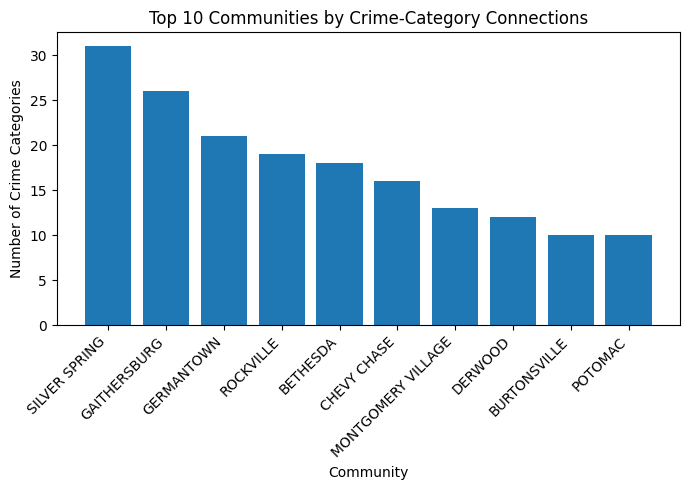

In [88]:
top_10_degree = community_degree.head(10)

plt.figure(figsize=(7, 5))

plt.bar(
    top_10_degree["City"],
    top_10_degree["Crime_Category_Connections"]
)

plt.xlabel("Community")
plt.ylabel("Number of Crime Categories")
plt.title("Top 10 Communities by Crime-Category Connections")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [89]:
importance_table = community_degree.merge(
    weighted_degree,
    on="City"
)

importance_table.head(10)

,City,Crime_Category_Connections,Total_Reported_Incidents
0,SILVER SPRING,31,465
1,GAITHERSBURG,26,97
2,GERMANTOWN,21,139
3,ROCKVILLE,19,112
4,BETHESDA,18,95
5,CHEVY CHASE,16,35
6,MONTGOMERY VILLAGE,13,30
7,DERWOOD,12,24
8,BURTONSVILLE,10,22
9,POTOMAC,10,16


Question:  
Which communities are connected to the greatest variety of reported crime categories during August 31 to 22, 2026?

Stakeholder:  
MCPD crime analysts/public-safety planning staff.

Node:  
Community or crime category.

Edge:  
A reported crime category occurred in a community.

Weight:  
Number of reported incidents connecting the community and crime category.

Importance:  
Degree = number of distinct crime categories connected to a community.

In [91]:
#Validating data below
print("Original records:", len(data))
print("MCPD records:", len(data_mcpd))
print("Network records:", len(data_network))

print("\nAll Other Offenses remaining:")
print(
    data_network["Crime Name2"]
    .str.strip()
    .eq("All Other Offenses")
    .sum()
)

print("\nNetwork:")
print(g)

print("\nTop 3 communities by degree:")
print(community_degree.head(3))

print("\nTop 3 communities by weighted degree:")
print(weighted_degree.head(3))

Original records: 2004
MCPD records: 1617
Network records: 1103

All Other Offenses remaining:
0

Network:
Graph with 60 nodes and 224 edges

Top 3 communities by degree:
             City  Crime_Category_Connections
21  SILVER SPRING                          31
10   GAITHERSBURG                          26
11     GERMANTOWN                          21

Top 3 communities by weighted degree:
             City  Total_Reported_Incidents
21  SILVER SPRING                       465
11     GERMANTOWN                       139
19      ROCKVILLE                       112


Here, I checked to make sure all records for each input I made in Colab were correct and filtered for each category needed, such as MCPD agency, and making sure no other offenses were involved in the network dataset. We see the number of nodes and edges, and compared the degree results against different groups from the dataset.

Lastly, Making the Actual Network Figure.

In attempt to make this figure, I have asked ChatGPT in order to generate code that helps me make a figure to show the network between the citites and crime categories to see the comparison. Below is the network figure using my Existing Network x code.

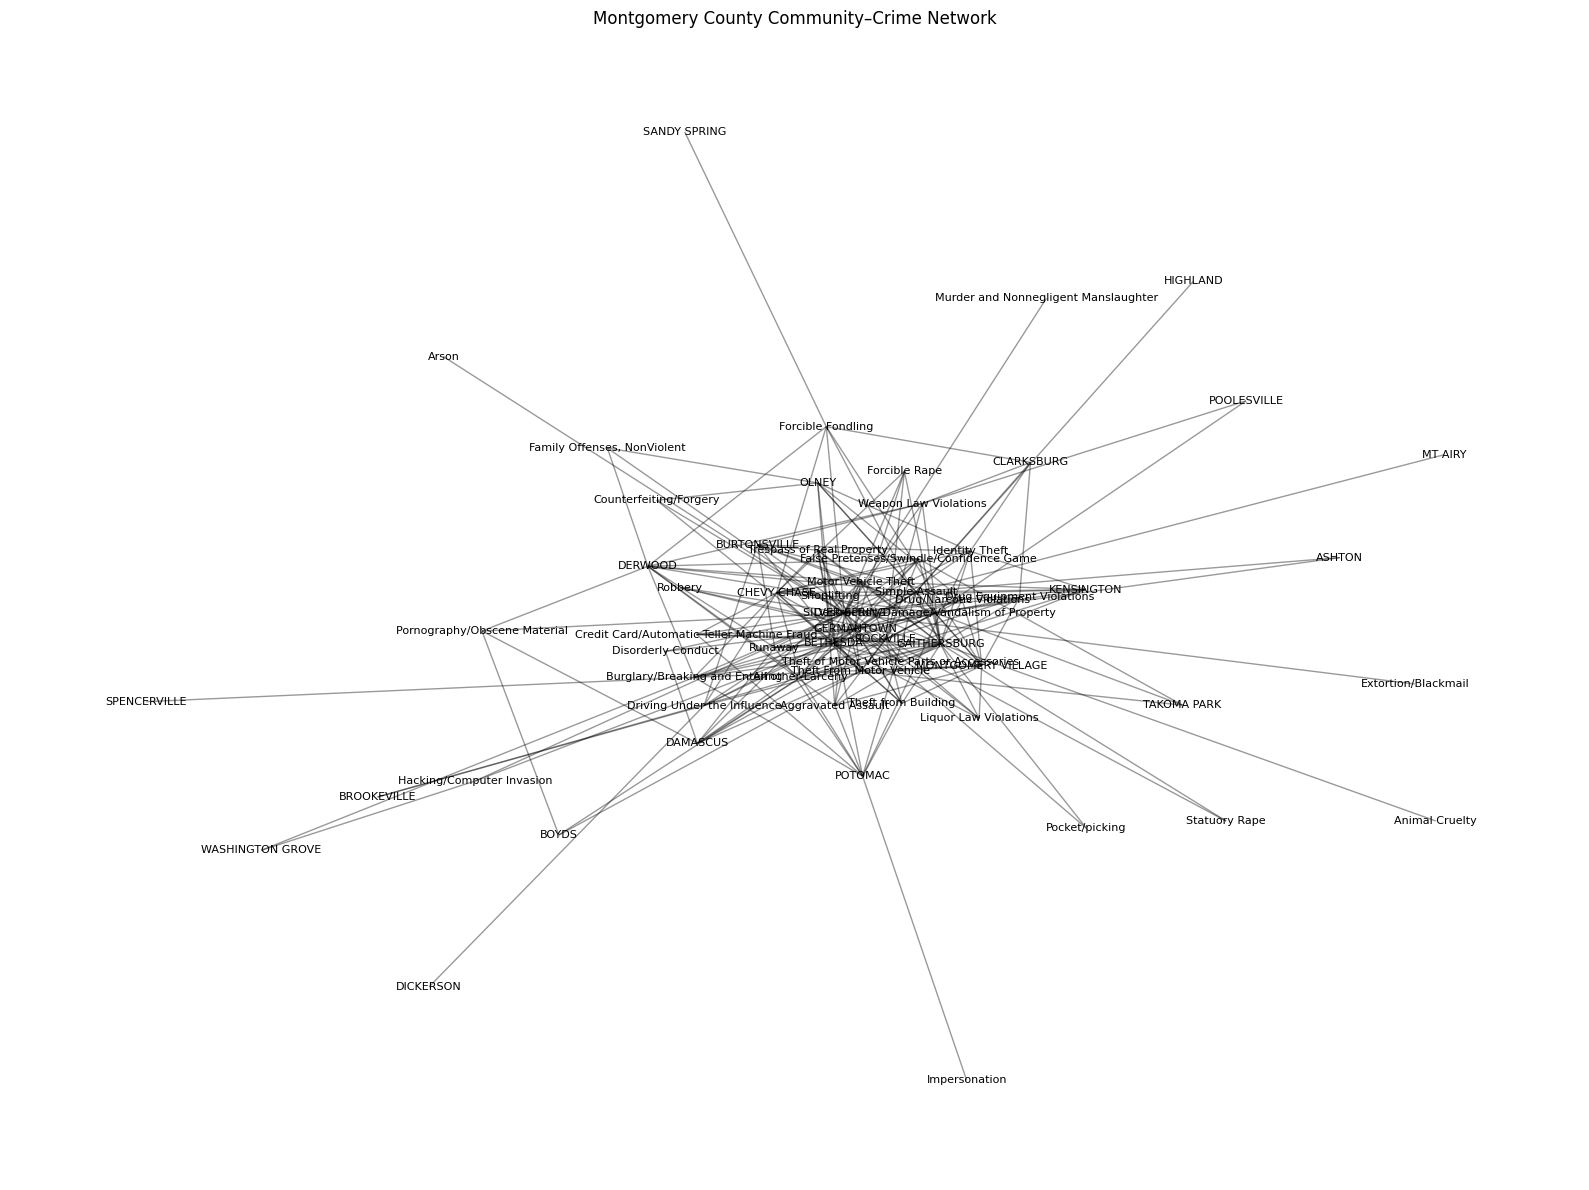

In [93]:
import matplotlib.pyplot as plt
import networkx as nx

# Separate the two types of nodes
community_nodes = [
    node for node, data in g.nodes(data=True)
    if data["node_type"] == "community"
]

crime_nodes = [
    node for node, data in g.nodes(data=True)
    if data["node_type"] == "crime"
]

# Create a layout for the network
pos = nx.spring_layout(g, seed=42)

# Create the figure
plt.figure(figsize=(16, 12))

# Draw community nodes
nx.draw_networkx_nodes(
    g,
    pos,
    nodelist=community_nodes,
    node_color="lightblue",
    node_size=800,
    node_shape="o"
)

# Draw crime-category nodes
nx.draw_networkx_nodes(
    g,
    pos,
    nodelist=crime_nodes,
    node_color="lightcoral",
    node_size=500,
    node_shape="s"
)

# Draw edges
nx.draw_networkx_edges(
    g,
    pos,
    alpha=0.4
)

# Draw labels
nx.draw_networkx_labels(
    g,
    pos,
    font_size=8
)

plt.title("Montgomery County Community–Crime Network")
plt.axis("off")
plt.tight_layout()
plt.show()

Clearly, you cannot see the huge picture of the network, but it's still a great image to see how huge the network is and its connections toward one another. Instead, I will make one more visualization using the help from ChatGPT, Ensuring that the Top 3 communities is demonstrated to be part of the network with many crime categories connecting edges to them, and display the node and edge network.

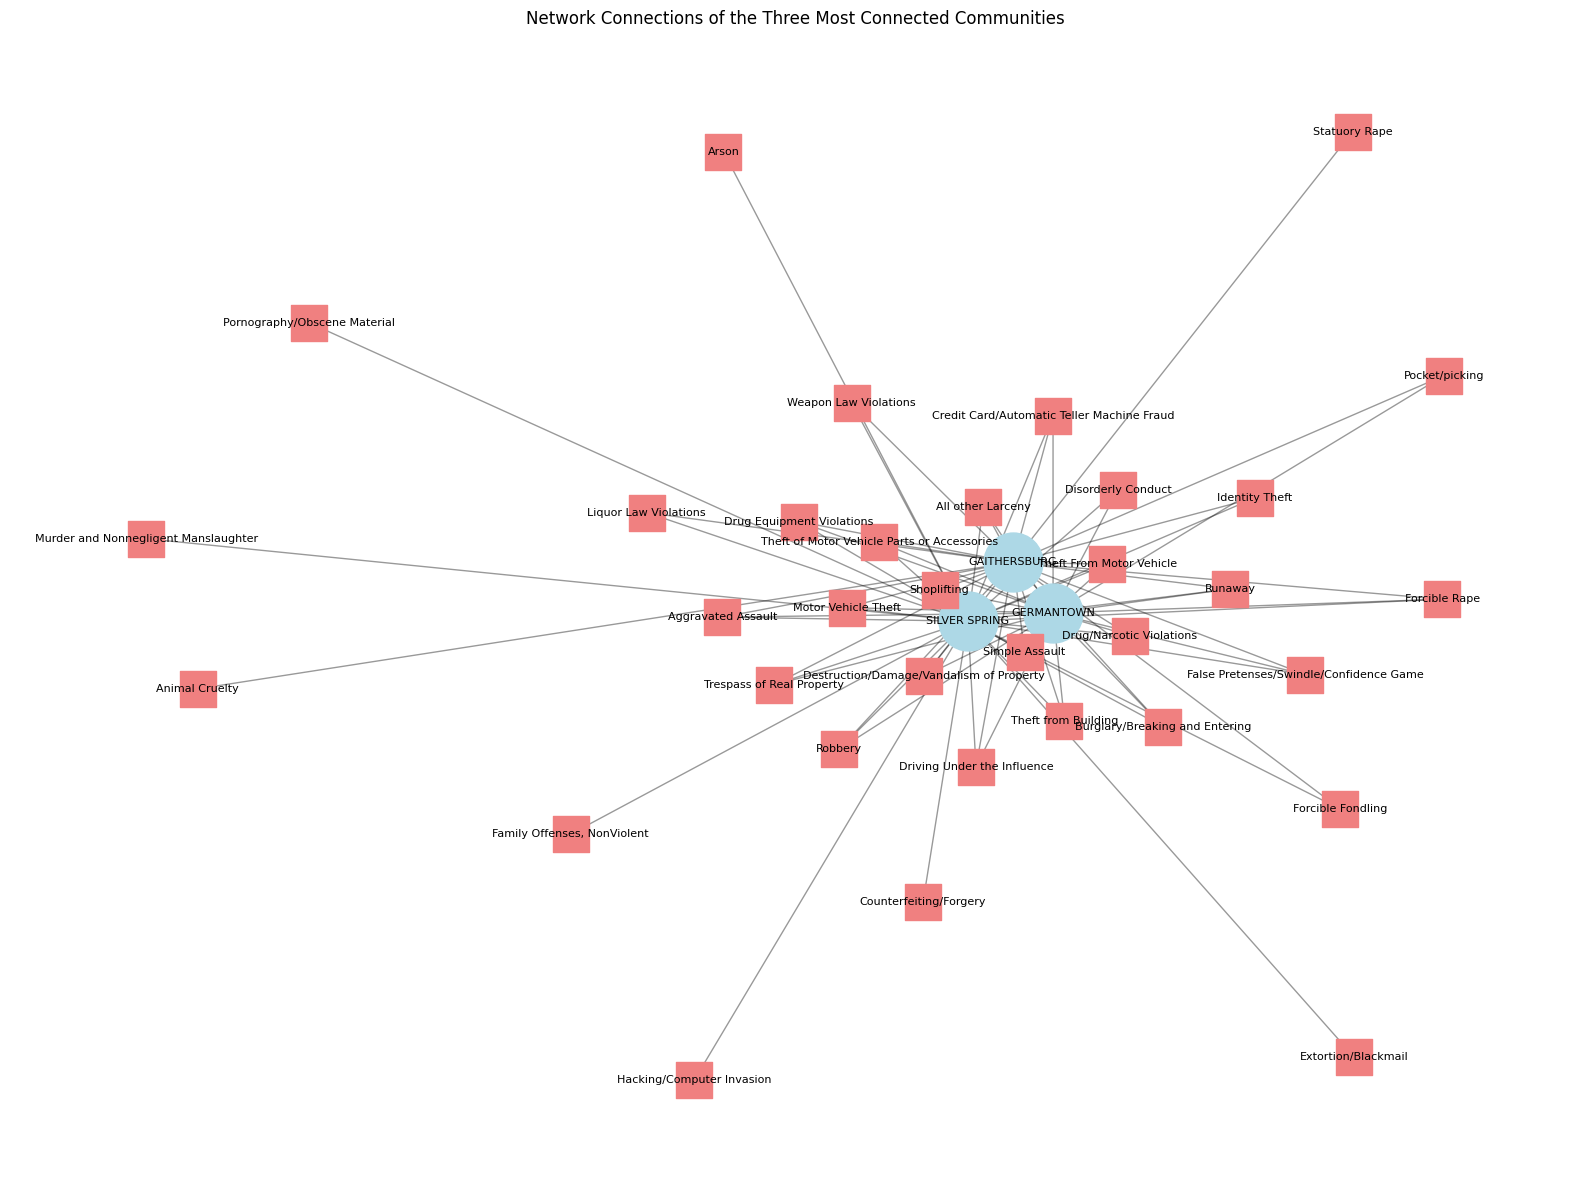

In [94]:
# Our three most important community nodes
top_3 = [
    "SILVER SPRING",
    "GAITHERSBURG",
    "GERMANTOWN"
]

# Find all crime categories connected to those communities
crime_neighbors = set()

for city in top_3:
    crime_neighbors.update(g.neighbors(city))

# Create a smaller subgraph
important_nodes = top_3 + list(crime_neighbors)

subgraph = g.subgraph(important_nodes)

# Create layout
pos = nx.spring_layout(subgraph, seed=42)

plt.figure(figsize=(16, 12))

# Draw community nodes
nx.draw_networkx_nodes(
    subgraph,
    pos,
    nodelist=top_3,
    node_color="lightblue",
    node_size=1800,
    node_shape="o"
)

# Draw crime nodes
crime_subgraph_nodes = [
    node for node in subgraph.nodes()
    if node not in top_3
]

nx.draw_networkx_nodes(
    subgraph,
    pos,
    nodelist=crime_subgraph_nodes,
    node_color="lightcoral",
    node_size=700,
    node_shape="s"
)

# Draw edges
nx.draw_networkx_edges(
    subgraph,
    pos,
    alpha=0.4
)

# Draw labels
nx.draw_networkx_labels(
    subgraph,
    pos,
    font_size=8
)

plt.title(
    "Network Connections of the Three Most Connected Communities"
)

plt.axis("off")
plt.tight_layout()
plt.show()

Network connections for the three communities with the highest degree.

(Circles represent communities and squares represent reported crime categories. Edges show that a crime category was reported in a community.)